# Circuitos críticos de Ternium — Modelo de clasificación (XGBoost)

**Proyecto:** Aseguramiento del Abastecimiento a Líneas Críticas (Ternium) · Fase 3 · Modelado.

La idea de este notebook es entrenar un clasificador que separe los circuitos críticos de los que no lo son, usando nada más variables operativas.

Antes de modelar tuvimos que arreglar un detalle importante. El target `score_prioridad` no es una etiqueta que alguien haya observado en planta; es un índice que el propio equipo calculó a partir de unas cuantas variables operativas. Si dejamos esas variables como entradas del modelo, el modelo en realidad no aprende a predecir nada: simplemente recompone la fórmula con la que se armó el target. Eso infla las métricas y no sirve de mucho en la práctica.

Así que aquí lo hacemos de forma honesta. Primero mostramos por qué pasaba eso, después quitamos las variables que causan el problema y entrenamos el XGBoost solo con señales indirectas. El modelo que queda es más modesto en números, pero esos números sí miden capacidad predictiva real.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    RepeatedStratifiedKFold, StratifiedKFold, cross_val_score, cross_val_predict,
    train_test_split,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
)
from xgboost import XGBClassifier

import optuna
from optuna.samplers import TPESampler
import warnings

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

RNG = 42
VERDE, VERDE_CLARO, GRIS, NARANJA = "#1D9E75", "#5DCAA5", "#B4B2A9", "#D85A30"

## 1. Carga de datos

Cada fila es un circuito (planta origen, destino y tipo de camión) con sus variables operativas. Nos quedamos solo con los circuitos que tienen `score_prioridad`, que son los que cuentan con datos de tiempo de tránsito. Eso baja la muestra de 553 a 318 circuitos.

El target lo definimos igual que acordó el equipo: un circuito es crítico (1) si su `score_prioridad` cae en el 25 % más alto (percentil 75), y no crítico (0) en caso contrario. Queda desbalanceado, más o menos 75/25.

In [2]:
df = pd.read_csv("tabla_circuitos_filtrada.csv")

print(f"Circuitos totales: {len(df)}")
print(f"Con score_prioridad: {df.score_prioridad.notna().sum()}")
print(f"Sin score_prioridad (sin tiempo de tránsito): {df.score_prioridad.isna().sum()}")

df = df.dropna(subset=["score_prioridad"]).reset_index(drop=True)

umbral_p75 = df.score_prioridad.quantile(0.75)
df["target"] = (df.score_prioridad >= umbral_p75).astype(int)

print(f"\nCircuitos tras filtrar: {len(df)}")
print(f"Umbral percentil 75: {umbral_p75:.4f}")
print("\nDistribución del target (1 = crítico):")
print(df.target.value_counts().to_frame("conteo"))
print(df.target.value_counts(normalize=True).round(3).to_frame("proporción"))

Circuitos totales: 553
Con score_prioridad: 318
Sin score_prioridad (sin tiempo de tránsito): 235

Circuitos tras filtrar: 318
Umbral percentil 75: 0.2173

Distribución del target (1 = crítico):
        conteo
target        
0          238
1           80
        proporción
target            
0            0.748
1            0.252


## 2. Por qué no podemos usar cualquier variable

`score_prioridad` se armó como una combinación de cuatro variables operativas. Para comprobarlo intentamos reconstruir el score a partir de esas cuatro con una regresión lineal. Si de verdad es una fórmula de esas variables, el ajuste tiene que salir perfecto.

In [3]:
INGREDIENTES = [
    "proporcion_linea_critica",
    "frecuencia_viajes",
    "tiempo_transito_mediano_h",
    "proporcion_anomalia_tiempo",
]

# normalizamos cada variable a [0, 1] antes de ajustar
norm = pd.DataFrame(index=df.index)
for c in INGREDIENTES:
    v = df[c].astype(float)
    norm[c] = (v - v.min()) / (v.max() - v.min())

ols = LinearRegression(positive=True).fit(norm.values, df.score_prioridad.values)
r2 = ols.score(norm.values, df.score_prioridad.values)

print(f"R² al reconstruir el score con esas 4 variables: {r2:.6f}\n")
print("score_prioridad ≈")
for c, w in sorted(zip(INGREDIENTES, ols.coef_), key=lambda t: -t[1]):
    print(f"   {w:6.3f} · norm({c})")
print(f"   + {ols.intercept_:.4f}")

R² al reconstruir el score con esas 4 variables: 1.000000

score_prioridad ≈
    0.335 · norm(proporcion_linea_critica)
    0.250 · norm(frecuencia_viajes)
    0.200 · norm(tiempo_transito_mediano_h)
    0.173 · norm(proporcion_anomalia_tiempo)
   + 0.0003


El R² da prácticamente 1.0, así que el target es exactamente esa fórmula. Meter esas cuatro variables al modelo sería hacer trampa: no predeciría criticidad, solo despejaría la cuenta. Por eso las dejamos fuera.

## 3. Qué variables entran al modelo

Para entrenar de forma honesta quitamos:

- Las cuatro variables que definen el score: `proporcion_linea_critica`, `frecuencia_viajes`, `tiempo_transito_mediano_h` y `proporcion_anomalia_tiempo`.
- Dos variables que son casi copias de las anteriores y volverían a meter la fuga por la puerta de atrás: `participacion_total` (correlación 1.00 con `frecuencia_viajes`) y `tiempo_transito_promedio_h` (correlación 0.98 con la mediana del tiempo de tránsito).

Lo que le dejamos al modelo son señales indirectas: pesos, dimensiones, qué tan dispersos son los tiempos, los indicadores de material y las tres categóricas (origen, destino y tipo de camión).

Para las categóricas usamos *frequency encoding*: cambiamos cada categoría por cuántos circuitos hay de ella. Lo preferimos sobre el Label Encoding porque ese le pone un orden numérico falso a cosas que no tienen orden (DESTINO tiene 37 valores distintos) y deja que el modelo se aprenda identidades de memoria.

In [4]:
# imputamos los pocos nulos de tiempo_transito_std_h con la mediana
df["tiempo_transito_std_h"] = df["tiempo_transito_std_h"].fillna(df["tiempo_transito_std_h"].median())

# frequency encoding de las categóricas
CATEGORICAS = ["PLANTA_ORIGEN", "DESTINO", "NOMBRE_TIPO_CAMION"]
for c in CATEGORICAS:
    df[c + "_freq"] = df[c].map(df[c].value_counts())
cat_freq = [c + "_freq" for c in CATEGORICAS]

# variables operativas indirectas (sin los 4 ingredientes del score ni sus 2 proxies)
features = [
    "frecuencia_registros", "tiempo_transito_std_h", "tiempo_transito_iqr_h",
    "peso_promedio", "peso_mediano", "peso_bruto_promedio",
    "ancho_promedio", "espesor_promedio", "material_pesado", "material_ancho",
] + cat_freq

X = StandardScaler().fit_transform(df[features].fillna(0))
y = df.target.values

print(f"Variables que entran al modelo: {len(features)}")
for f in features:
    print(f"  - {f}")

Variables que entran al modelo: 13
  - frecuencia_registros
  - tiempo_transito_std_h
  - tiempo_transito_iqr_h
  - peso_promedio
  - peso_mediano
  - peso_bruto_promedio
  - ancho_promedio
  - espesor_promedio
  - material_pesado
  - material_ancho
  - PLANTA_ORIGEN_freq
  - DESTINO_freq
  - NOMBRE_TIPO_CAMION_freq


## 4. Ajuste de hiperparámetros con Optuna

Buscamos los hiperparámetros de XGBoost con Optuna. Optimizamos PR-AUC (*average precision*) porque, con clases desbalanceadas, es la métrica que mejor refleja qué tan bien encontramos a la clase minoritaria, que aquí es justo la que nos importa (los críticos). Usamos validación cruzada estratificada repetida para que la búsqueda no se acomode al ruido de una sola partición.

In [5]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500, step=50),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 5.0),
        "eval_metric": "logloss", "random_state": RNG,
    }
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RNG)
    return cross_val_score(XGBClassifier(**params), X, y, cv=cv,
                           scoring="average_precision", n_jobs=-1).mean()

study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=RNG))
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f"\nMejor PR-AUC (CV): {study.best_value:.4f}")
print("Mejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

params_finales = dict(study.best_params, eval_metric="logloss", random_state=RNG)
modelo_final = XGBClassifier(**params_finales)

  0%|          | 0/40 [00:00<?, ?it/s]


Mejor PR-AUC (CV): 0.7880
Mejores hiperparámetros:
  n_estimators: 400
  max_depth: 3
  learning_rate: 0.14966852946389317
  subsample: 0.6889420748911643
  colsample_bytree: 0.7644989996372487
  reg_alpha: 0.40043212170526665
  reg_lambda: 4.7175536939722775
  scale_pos_weight: 3.088360290130076


## 5. Evaluación del modelo

Para evaluar no usamos un solo split de test: con tan pocos circuitos sería muy ruidoso. En su lugar usamos predicciones *out-of-fold*. Partimos los datos en 5 folds y a cada circuito lo predecimos con un modelo que no lo vio durante su entrenamiento. Así los 318 circuitos terminan con una predicción honesta y la matriz de confusión queda mucho más estable.

In [6]:
cv_oof = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
y_oof = cross_val_predict(modelo_final, X, y, cv=cv_oof, n_jobs=-1)
proba_oof = cross_val_predict(modelo_final, X, y, cv=cv_oof, n_jobs=-1,
                              method="predict_proba")[:, 1]

print("Modelo final (out-of-fold, 318 circuitos):")
print(f"  Accuracy: {accuracy_score(y, y_oof):.4f}")
print(f"  F1-score: {f1_score(y, y_oof):.4f}")
print(f"  AUC-ROC:  {roc_auc_score(y, proba_oof):.4f}")
print(f"  PR-AUC:   {average_precision_score(y, proba_oof):.4f}")
print("\n" + classification_report(y, y_oof, target_names=["No Crítico (0)", "Crítico (1)"]))

Modelo final (out-of-fold, 318 circuitos):
  Accuracy: 0.8553
  F1-score: 0.7160
  AUC-ROC:  0.9020
  PR-AUC:   0.7773

                precision    recall  f1-score   support

No Crítico (0)       0.91      0.90      0.90       238
   Crítico (1)       0.71      0.72      0.72        80

      accuracy                           0.86       318
     macro avg       0.81      0.81      0.81       318
  weighted avg       0.86      0.86      0.86       318



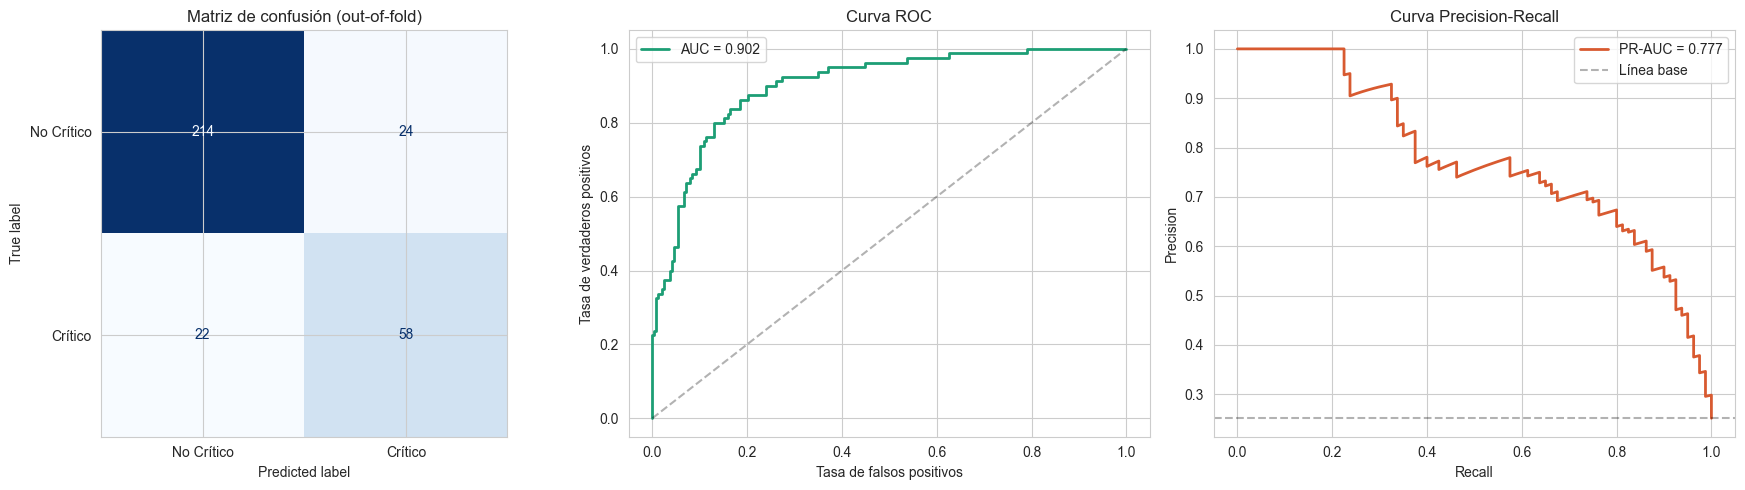

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y, y_oof)
ConfusionMatrixDisplay(cm, display_labels=["No Crítico", "Crítico"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matriz de confusión (out-of-fold)")

fpr, tpr, _ = roc_curve(y, proba_oof)
axes[1].plot(fpr, tpr, color=VERDE, lw=2, label=f"AUC = {roc_auc_score(y, proba_oof):.3f}")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].set_title("Curva ROC")
axes[1].legend()

prec, rec, _ = precision_recall_curve(y, proba_oof)
axes[2].plot(rec, prec, color=NARANJA, lw=2,
             label=f"PR-AUC = {average_precision_score(y, proba_oof):.3f}")
axes[2].axhline(y.mean(), color="k", ls="--", alpha=0.3, label="Línea base")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].set_title("Curva Precision-Recall")
axes[2].legend()

plt.tight_layout()
plt.show()

## 6. Qué variables pesan más

Vemos la importancia de dos maneras. La de XGBoost (por ganancia) mide cuánto usó cada variable para partir los árboles. La de permutación es más confiable: mide cuánto empeora el modelo sobre datos de test cuando revolvemos una variable. Si revolverla no afecta, esa variable no estaba aportando.

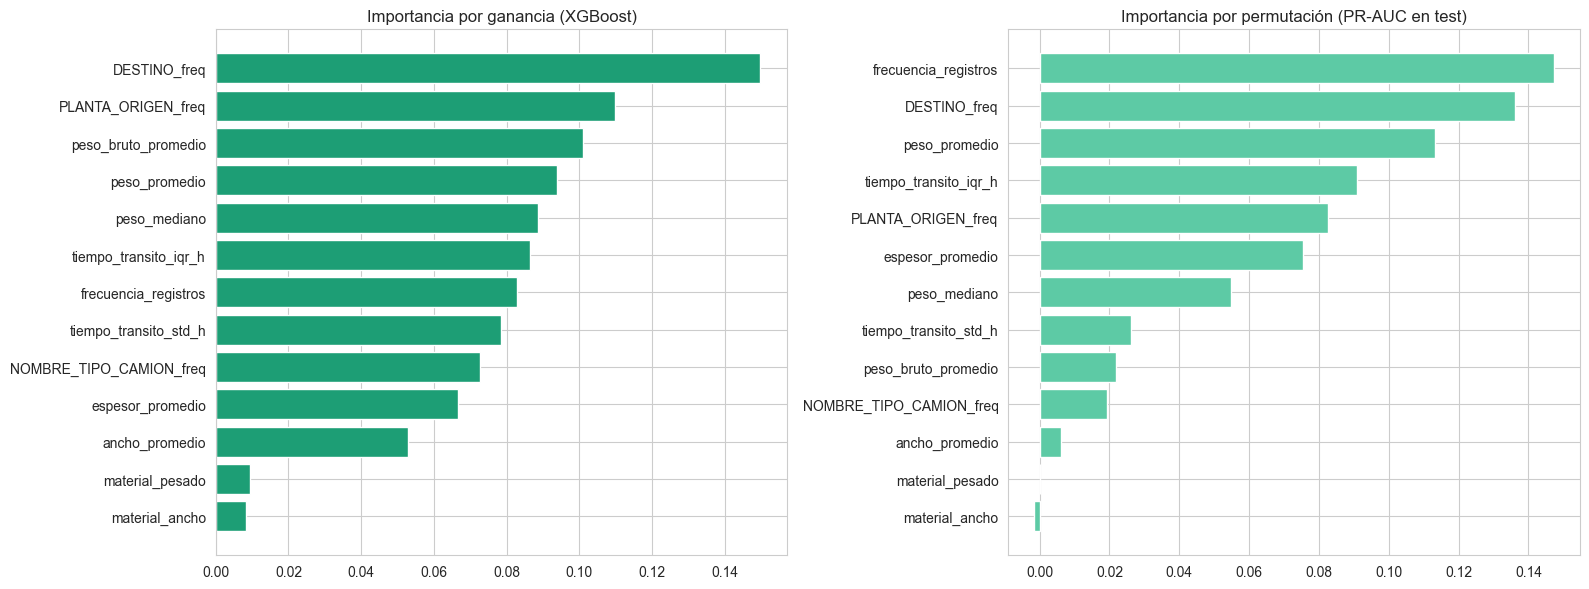

Top 5 variables (permutación):
  +0.1473  frecuencia_registros
  +0.1362  DESTINO_freq
  +0.1133  peso_promedio
  +0.0910  tiempo_transito_iqr_h
  +0.0826  PLANTA_ORIGEN_freq


In [8]:
modelo_final.fit(X, y)
imp_gain = pd.DataFrame({"feature": features,
                         "importancia": modelo_final.feature_importances_}
                        ).sort_values("importancia", ascending=True)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=RNG, stratify=y)
m_perm = XGBClassifier(**params_finales).fit(Xtr, ytr)
perm = permutation_importance(m_perm, Xte, yte, scoring="average_precision",
                              n_repeats=30, random_state=RNG)
imp_perm = pd.DataFrame({"feature": features,
                         "importancia": perm.importances_mean}
                        ).sort_values("importancia", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(imp_gain.feature, imp_gain.importancia, color=VERDE)
axes[0].set_title("Importancia por ganancia (XGBoost)")
axes[1].barh(imp_perm.feature, imp_perm.importancia, color=VERDE_CLARO)
axes[1].set_title("Importancia por permutación (PR-AUC en test)")
plt.tight_layout()
plt.show()

print("Top 5 variables (permutación):")
for _, r in imp_perm.tail(5).iloc[::-1].iterrows():
    print(f"  {r.importancia:+.4f}  {r.feature}")

## 7. Ranking de circuitos para priorizar

Más allá del clasificador, lo que Ternium puede usar directo es la lista de circuitos ordenada por `score_prioridad`. Mostramos el top 15 junto con los componentes que más pesan en el índice, para que se entienda por qué cada uno quedó arriba.

In [9]:
ranking = (df.sort_values("score_prioridad", ascending=False)
             [["CIRCUITO", "score_prioridad", "target",
               "proporcion_linea_critica", "frecuencia_viajes",
               "tiempo_transito_mediano_h", "proporcion_anomalia_tiempo"]]
             .head(15).reset_index(drop=True))
ranking["score_prioridad"] = ranking["score_prioridad"].round(4)
print("Top 15 circuitos por prioridad:")
display(ranking)

Top 15 circuitos por prioridad:


,CIRCUITO,score_prioridad,target,proporcion_linea_critica,frecuencia_viajes,tiempo_transito_mediano_h,proporcion_anomalia_tiempo
0,Pesquería -> Churubusco | Plataforma 3 ejes Ne...,0.5155,1,0.742839,6166,1.783333,0.016752
1,Juventud -> CSI San Luis Potosí | Plataforma 2...,0.4050,1,0.272727,6,115.616667,0.863636
2,Pesquería -> CSI Apodaca | Plataforma 2 ejes N...,0.3631,1,0.950000,7,8.750000,0.100000
3,Churubusco -> Guerrero | Plataforma 3 ejes Neu...,0.3533,1,0.957447,388,0.266667,0.010638
4,Pesquería -> CSI San Luis Potosí | Plataforma ...,0.3506,1,0.448276,19,75.766667,0.517241
5,Churubusco -> Planos Guerrero | Plataforma 3 e...,0.3387,1,0.912356,428,0.266667,0.008621
6,Monclova -> CSI San Luis Potosí | Plataforma 3...,0.3373,1,0.467354,43,74.650000,0.419244
7,Pesquería -> CSI San Luis Potosí | Plataforma ...,0.3344,1,0.528000,117,71.200000,0.304000
8,Pesquería -> Universidad | Plataforma 3 Ejes N...,0.3292,1,0.833333,5,3.366667,0.166667
9,Pesquería -> Churubusco | Plataforma 3 ejes Ne...,0.3291,1,0.671387,2126,1.916667,0.028052


In [10]:
salida = df[["CIRCUITO", "score_prioridad", "target"]].copy()
salida["pred_oof"] = y_oof
salida["proba_critico_oof"] = proba_oof.round(4)
salida.to_csv("predicciones_modelo_honesto.csv", index=False)
print("Guardado: predicciones_modelo_honesto.csv")

Guardado: predicciones_modelo_honesto.csv


## 8. Conclusiones

- El target `score_prioridad` es un índice calculado, no una etiqueta observada. Si se entrena con las variables que lo definen, las métricas salen casi perfectas, pero son un espejismo: el modelo nada más recompone la fórmula.
- Quitando esas variables y sus proxies, predecir la criticidad sigue siendo posible a partir de señales indirectas, con un AUC del orden de 0.85–0.90 (lejos del 0.99 inflado). Es un número más modesto pero real, y ese es el desempeño que reportaríamos.
- Las variables que más aportan en este modelo honesto son el destino, la dispersión de los tiempos de tránsito y los atributos del material.

**Lo que falta y siguientes pasos:**

- Lo ideal sería que Ternium nos diera una definición de criticidad basada en negocio (paros de línea reales, impacto, urgencia) en lugar de un índice sintético. Con esa etiqueta el modelo se podría validar de verdad.
- Dejamos fuera el 42 % de los circuitos por no tener tiempo de tránsito. Recuperar esos datos ampliaría la muestra y la haría menos sesgada.

In [11]:
print("="*60)
print("RESUMEN — Modelo honesto de circuitos críticos")
print("="*60)
print(f"  Circuitos:   {len(df)}  (críticos: {int(df.target.sum())})")
print(f"  Target:      score_prioridad >= p75 ({umbral_p75:.4f})")
print(f"  Variables:   {len(features)} (operativas indirectas, sin fuga)")
print()
print(f"  Accuracy:    {accuracy_score(y, y_oof):.4f}")
print(f"  F1-score:    {f1_score(y, y_oof):.4f}")
print(f"  AUC-ROC:     {roc_auc_score(y, proba_oof):.4f}")
print(f"  PR-AUC:      {average_precision_score(y, proba_oof):.4f}")

RESUMEN — Modelo honesto de circuitos críticos
  Circuitos:   318  (críticos: 80)
  Target:      score_prioridad >= p75 (0.2173)
  Variables:   13 (operativas indirectas, sin fuga)

  Accuracy:    0.8553
  F1-score:    0.7160
  AUC-ROC:     0.9020
  PR-AUC:      0.7773
